# 🧠 BƯỚC 5: Sentiment Analysis
## Phần B — Deep Learning (TextCNN + BiLSTM + DistilBERT)

---
### 🎯 Mục tiêu:
Train 3 model Deep Learning để so sánh với Traditional ML:
- **TextCNN** : CNN-based, nhanh nhất
- **BiLSTM**  : RNN-based, hiểu sequential context
- **DistilBERT**: Transformer, tốt nhất

### 📊 Data sử dụng:
```
TextCNN  + BiLSTM  : 1M reviews
DistilBERT         : 300k reviews
```

### ⚙️ Yêu cầu:
- **GPU T4** (bắt buộc cho DistilBERT)
- Runtime: GPU T4

## Cell 0 — Mount Drive & Cài thư viện

In [2]:
# ============================================================
# CELL 0: Setup môi trường
#
# torch       : framework Deep Learning chính
# transformers: HuggingFace → dùng cho DistilBERT
# pyarrow     : đọc file .parquet
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

!pip install torch transformers pyarrow scikit-learn -q

# Kiểm tra GPU
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'   GPU available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   GPU name      : {torch.cuda.get_device_name(0)}')
    print(f'   GPU memory    : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'   Device        : {DEVICE}')

Mounted at /content/drive
PyTorch version: 2.10.0+cpu
   GPU available : False
   Device        : cpu


## Cell 1 — Import & Setup

In [3]:
# ============================================================
# CELL 1: Import thư viện
#
# torch.nn     : các layer của neural network
# DataLoader   : load data theo batch khi train
# Dataset      : custom dataset class
# ============================================================

import numpy as np
import pandas as pd
import json, re, gc, time
from pathlib import Path
from collections import Counter
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Sklearn metrics
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from tqdm.auto import tqdm

# Đường dẫn
DRIVE_ROOT    = Path('/content/drive/MyDrive/amazon_clothing')
PROCESSED_DIR = DRIVE_ROOT / 'data' / 'processed'
MODELS_DIR    = DRIVE_ROOT / 'outputs' / 'models'
FIGURES_DIR   = DRIVE_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LABEL_NAMES = ['negative', 'neutral', 'positive']
LABEL_MAP   = {'negative': 0, 'neutral': 1, 'positive': 2}

# Config data
N_SAMPLES_CNN_LSTM = 1_000_000   # TextCNN và BiLSTM
N_SAMPLES_BERT     = 300_000     # DistilBERT
SPLIT_YEAR         = 2022        # train < 2022, test >= 2022

print('✅ Setup xong!')
print(f'   Device: {DEVICE}')

✅ Setup xong!
   Device: cpu


## Cell 2 — Load & Chuẩn bị data

In [6]:
# ============================================================
# CELL 2: Load raw text từ review_clean.parquet
#
# Deep Learning cần RAW TEXT (không phải TF-IDF vector)
# vì model tự học cách biểu diễn text qua embedding layer
#
# Chiến lược:
# → Load chunked để tránh OOM
# → Lấy đủ N_SAMPLES theo split năm
# ============================================================

def load_text_data(n_train, n_test_ratio=0.2):
    """
    Load raw text reviews từ parquet — SAMPLE NGẪU NHIÊN
    để đảm bảo đại diện cho toàn bộ dataset
    """
    pf        = pq.ParquetFile(PROCESSED_DIR / 'review_clean.parquet')
    n_rg      = pf.metadata.num_row_groups
    n_total   = n_train + int(n_train * n_test_ratio)

    # Tính sample rate để lấy đủ n_total samples
    total_rows  = pf.metadata.num_rows
    sample_rate = min(1.0, (n_total * 1.5) / total_rows)  # × 1.5 để dư sau khi lọc

    all_texts, all_labels, all_years = [], [], []

    print(f'📦 Loading data (target: {n_total:,} | sample_rate: {sample_rate:.3f})...')

    for rg_idx in tqdm(range(n_rg), desc='Loading'):
        # Dừng sớm nếu đã đủ data
        if len(all_texts) >= n_total * 1.2:
            break

        chunk = pf.read_row_group(
            rg_idx,
            columns=['text', 'sentiment', 'year']
        ).to_pandas()
        chunk = chunk.dropna(subset=['text', 'sentiment', 'year'])

        # Sample ngẫu nhiên từ mỗi chunk
        n_take = max(1, int(len(chunk) * sample_rate))
        chunk  = chunk.sample(n=min(n_take, len(chunk)),
                               random_state=rg_idx)  # random_state=rg_idx để đa dạng

        chunk['text']  = chunk['text'].astype(str).str.lower()
        chunk['text']  = chunk['text'].str.replace(r'[^a-z\s]', ' ', regex=True)
        chunk['text']  = chunk['text'].str.replace(r'\s+', ' ', regex=True).str.strip()
        chunk['label'] = chunk['sentiment'].map(LABEL_MAP)
        chunk          = chunk.dropna(subset=['label'])
        chunk['label'] = chunk['label'].astype(int)

        all_texts.extend(chunk['text'].tolist())
        all_labels.extend(chunk['label'].tolist())
        all_years.extend(chunk['year'].tolist())

        del chunk
        gc.collect()

    # Shuffle toàn bộ trước khi split
    from sklearn.utils import shuffle as sk_shuffle
    all_texts, all_labels, all_years = sk_shuffle(
        all_texts, all_labels, all_years, random_state=42
    )

    # Split theo năm (không phải theo thứ tự sau shuffle)
    train_texts  = [t for t, y in zip(all_texts, all_years) if y < SPLIT_YEAR][:n_train]
    train_labels = [l for l, y in zip(all_labels, all_years) if y < SPLIT_YEAR][:n_train]
    test_texts   = [t for t, y in zip(all_texts, all_years) if y >= SPLIT_YEAR][:int(n_train * n_test_ratio)]
    test_labels  = [l for l, y in zip(all_labels, all_years) if y >= SPLIT_YEAR][:int(n_train * n_test_ratio)]

    del all_texts, all_labels, all_years
    gc.collect()

    print(f'✅ Loaded: {len(train_texts):,} train | {len(test_texts):,} test')
    print(f'   Split: train < {SPLIT_YEAR} | test >= {SPLIT_YEAR}')

    for split, labels in [('Train', train_labels), ('Test', test_labels)]:
        print(f'   {split} distribution:')
        for i, name in enumerate(LABEL_NAMES):
            cnt = labels.count(i)
            print(f'     {name:10}: {cnt:,} ({cnt/len(labels)*100:.1f}%)')

    return train_texts, train_labels, test_texts, test_labels

# Load 1M cho TextCNN và BiLSTM
train_texts, train_labels, test_texts, test_labels = load_text_data(N_SAMPLES_CNN_LSTM)

📦 Loading data (target: 1,200,000 | sample_rate: 0.029)...


Loading:   0%|          | 0/661 [00:00<?, ?it/s]

✅ Loaded: 1,000,000 train | 200,000 test
   Split: train < 2022 | test >= 2022
   Train distribution:
     negative  : 130,882 (13.1%)
     neutral   : 86,183 (8.6%)
     positive  : 782,935 (78.3%)
   Test distribution:
     negative  : 31,790 (15.9%)
     neutral   : 18,391 (9.2%)
     positive  : 149,819 (74.9%)


## Cell 3 — Xây dựng Vocabulary

In [9]:
# ============================================================
# CELL 3: Xây dựng Vocabulary và Tokenizer
#
# Vocabulary = bảng ánh xạ từ → integer
# Ví dụ: {'good': 1, 'bad': 2, 'shirt': 3, ...}
#
# Tại sao cần?
# → Neural network chỉ hiểu số, không hiểu chữ
# → 'good' → 1 → embedding[1] → vector [0.2, 0.5, ...]
#
# MAX_VOCAB  : giới hạn vocabulary size để tránh OOM
# MAX_SEQ_LEN: cắt/pad text về độ dài cố định
#              → cần thiết vì batch cần cùng shape
# ============================================================

MAX_VOCAB   = 50_000   # giữ 50k từ phổ biến nhất
MAX_SEQ_LEN = 128      # mỗi review tối đa 128 từ

# Đếm tần suất từ từ training data
print('🔄 Building vocabulary...')
word_counter = Counter()
for text in tqdm(train_texts, desc='Counting words'):
    word_counter.update(text.split())

# Tạo vocab: giữ MAX_VOCAB từ phổ biến nhất
# PAD=0: padding token (điền vào chỗ trống)
# UNK=1: unknown token (từ không có trong vocab)
vocab      = {'<PAD>': 0, '<UNK>': 1}
most_common = word_counter.most_common(MAX_VOCAB - 2)
for word, _ in most_common:
    vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
print(f'✅ Vocabulary size: {VOCAB_SIZE:,}')
print(f'   Top 10 words: {[w for w, _ in most_common[:10]]}')

def tokenize(text, max_len=MAX_SEQ_LEN):
    """
    Chuyển text → list integer indices
    - Truncate nếu dài hơn max_len
    - Pad bằng 0 nếu ngắn hơn max_len
    """
    tokens = [vocab.get(w, 1) for w in text.split()[:max_len]]
    # Pad về đúng max_len
    tokens += [0] * (max_len - len(tokens))
    return tokens

# Test thử
sample = train_texts[0]
print(f'\n   Sample text (20 từ đầu): {" ".join(sample.split()[:20])}')
print(f'   Tokenized (10 đầu)     : {tokenize(sample)[:10]}')

🔄 Building vocabulary...


Counting words:   0%|          | 0/1000000 [00:00<?, ?it/s]

✅ Vocabulary size: 50,000
   Top 10 words: ['the', 'i', 'and', 'a', 'it', 'to', 'for', 'is', 'my', 'this']

   Sample text (20 từ đầu): crocs for both my husband self on our all tiled floors love them the fact that they save our feet
   Tokenized (10 đầu)     : [1121, 8, 302, 10, 207, 1726, 20, 361, 51, 10736]


## Cell 4 — Tạo PyTorch Dataset & DataLoader

In [10]:
# ============================================================
# CELL 4: Custom Dataset và DataLoader
#
# Dataset  : class chứa data, định nghĩa cách lấy 1 sample
# DataLoader: tự động chia thành batches, shuffle, parallel load
#
# Tại sao cần DataLoader?
# → Không thể train toàn bộ 1M reviews cùng lúc (OOM)
# → Chia thành batches 256 → train từng batch
# → Shuffle để model không học theo thứ tự
# ============================================================

class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        """
        texts : list of raw text strings
        labels: list of integer labels (0/1/2)
        """
        self.X = torch.tensor(
            [tokenize(t) for t in texts],
            dtype=torch.long
        )
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # Trả về 1 sample tại index idx
        return self.X[idx], self.y[idx]

BATCH_SIZE = 256

print('🔄 Tạo Dataset và DataLoader...')
train_dataset = SentimentDataset(train_texts, train_labels)
test_dataset  = SentimentDataset(test_texts,  test_labels)

train_loader  = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,       # shuffle mỗi epoch
    num_workers = 2,          # parallel loading
    pin_memory  = True        # tăng tốc copy sang GPU
)
test_loader   = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

print(f'✅ Dataset ready!')
print(f'   Train: {len(train_dataset):,} samples | {len(train_loader):,} batches')
print(f'   Test : {len(test_dataset):,} samples  | {len(test_loader):,} batches')
print(f'   Batch size: {BATCH_SIZE}')
print(f'   Input shape: {train_dataset[0][0].shape}')

🔄 Tạo Dataset và DataLoader...
✅ Dataset ready!
   Train: 1,000,000 samples | 3,907 batches
   Test : 200,000 samples  | 782 batches
   Batch size: 256
   Input shape: torch.Size([128])


## Cell 5 — Hàm Train & Evaluate chung

In [11]:
# ============================================================
# CELL 5: Hàm train và evaluate dùng chung cho tất cả model
#
# Quy trình train 1 epoch:
# 1. model.train()     → bật dropout, batchnorm
# 2. for batch in loader:
#    a. forward pass   → tính output
#    b. tính loss      → CrossEntropyLoss
#    c. backward pass  → tính gradient
#    d. optimizer.step → cập nhật weights
#
# CrossEntropyLoss:
# → Loss function chuẩn cho multi-class classification
# → Tự động kết hợp Softmax + NLLLoss
# → weight=class_weights để xử lý imbalanced data
# ============================================================

# Tính class weights để xử lý imbalanced
# Negative=14%, Neutral=8.5%, Positive=77.6%
# → class weight nghịch đảo tỷ lệ
label_counts  = Counter(train_labels)
total         = len(train_labels)
class_weights = torch.tensor([
    total / (3 * label_counts[i]) for i in range(3)
], dtype=torch.float).to(DEVICE)

print(f'Class weights: {class_weights.cpu().numpy().round(3)}')
print(f'  (negative={class_weights[0]:.2f}, neutral={class_weights[1]:.2f}, positive={class_weights[2]:.2f})')

criterion = nn.CrossEntropyLoss(weight=class_weights)

def train_epoch(model, loader, optimizer):
    """Train 1 epoch, trả về average loss"""
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()          # reset gradient
        outputs = model(X_batch)       # forward pass
        loss    = criterion(outputs, y_batch)  # tính loss
        loss.backward()                # backward pass
        optimizer.step()               # update weights

        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    """Evaluate model, trả về predictions và labels"""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():  # không tính gradient khi evaluate
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            outputs = model(X_batch)
            preds   = torch.argmax(outputs, dim=1)  # lấy class có prob cao nhất
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())

    return np.array(all_preds), np.array(all_labels)

def train_model(model, model_name, n_epochs=3):
    """Train model hoàn chỉnh và plot learning curve"""
    print(f'\n{"="*55}')
    print(f'🧠 Training: {model_name}')
    print(f'   Parameters: {sum(p.numel() for p in model.parameters()):,}')
    print(f'   Epochs    : {n_epochs}')
    print(f'{"="*55}')

    model     = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.5)

    train_losses = []
    best_f1      = 0
    t_total      = time.time()

    for epoch in range(n_epochs):
        t0 = time.time()
        print(f'\n  Epoch {epoch+1}/{n_epochs}:')

        # Train với tqdm
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f'  Train E{epoch+1}',
                     unit=' batch', leave=False)
        for X_batch, y_batch in pbar:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Evaluate
        y_pred, y_true = evaluate(model, test_loader)
        f1_mac  = f1_score(y_true, y_pred, average='macro')
        f1_wt   = f1_score(y_true, y_pred, average='weighted')
        elapsed = time.time() - t0

        print(f'  Loss={avg_loss:.4f} | F1-Macro={f1_mac:.4f} | '
              f'F1-Weighted={f1_wt:.4f} | Time={elapsed:.0f}s')

        # Lưu model tốt nhất
        if f1_mac > best_f1:
            best_f1 = f1_mac
            torch.save(model.state_dict(),
                       MODELS_DIR / f'sentiment_{model_name.lower().replace(" ","_")}_best.pt')
            print(f'  💾 Saved best model (F1={best_f1:.4f})')

        scheduler.step()  # giảm learning rate sau mỗi epoch

    total_time = time.time() - t_total
    print(f'\n✅ Training done! Total: {total_time/60:.1f} phút')

    # Load best model và evaluate lần cuối
    model.load_state_dict(
        torch.load(MODELS_DIR / f'sentiment_{model_name.lower().replace(" ","_")}_best.pt')
    )
    y_pred, y_true = evaluate(model, test_loader)

    f1_macro     = f1_score(y_true, y_pred, average='macro')
    f1_weighted  = f1_score(y_true, y_pred, average='weighted')
    f1_per_class = f1_score(y_true, y_pred, average=None)

    print(f'\n📊 Final Results:')
    print(f'   F1 Macro   : {f1_macro:.4f}')
    print(f'   F1 Weighted: {f1_weighted:.4f}')
    for name, f1 in zip(LABEL_NAMES, f1_per_class):
        bar = '█' * int(f1 * 20)
        print(f'   {name:10}: {bar:<20} {f1:.4f}')

    print(f'\n{classification_report(y_true, y_pred, target_names=LABEL_NAMES)}')

    # Confusion Matrix
    cm   = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'step5_cm_{model_name.lower().replace(" ","_")}.png',
                dpi=130, bbox_inches='tight')
    plt.show()

    # Plot loss curve
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, n_epochs+1), train_losses, 'b-o', linewidth=2)
    ax.set_title(f'Training Loss — {model_name}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'step5_loss_{model_name.lower().replace(" ","_")}.png',
                dpi=130, bbox_inches='tight')
    plt.show()

    return {
        'model'         : model_name,
        'train_time_s'  : round(total_time, 1),
        'train_time_fmt': f'{int(total_time//60):02d}:{int(total_time%60):02d}',
        'f1_macro'      : round(f1_macro, 4),
        'f1_weighted'   : round(f1_weighted, 4),
        'f1_negative'   : round(f1_per_class[0], 4),
        'f1_neutral'    : round(f1_per_class[1], 4),
        'f1_positive'   : round(f1_per_class[2], 4),
        'n_epochs'      : n_epochs,
        'train_samples' : len(train_labels),
    }

dl_results = {}
print('✅ Hàm train_model sẵn sàng!')

Class weights: [2.547 3.868 0.426]
  (negative=2.55, neutral=3.87, positive=0.43)
✅ Hàm train_model sẵn sàng!


---
# MODEL 1 — TextCNN

**Ý tưởng:**
```
Text → Embedding → Conv1D (nhiều kernel sizes) → MaxPool → FC → Output

Kernel sizes [2,3,4] = bắt bigram, trigram, 4-gram
MaxPool = lấy feature quan trọng nhất từ mỗi kernel
```

In [14]:
# ============================================================
# CELL 6: Kiến trúc TextCNN
#
# Embedding layer:
# → Chuyển integer index → dense vector (100 chiều)
# → Học được trong quá trình train
#
# Conv1D với nhiều kernel sizes:
# → kernel_size=2: bắt pattern 2 từ liên tiếp (bigram)
# → kernel_size=3: bắt pattern 3 từ (trigram)
# → kernel_size=4: bắt pattern 4 từ
# → Mỗi kernel có 128 filters → học 128 pattern khác nhau
#
# MaxPool (global):
# → Lấy giá trị lớn nhất của mỗi filter
# → Bất kể review dài ngắn → output cùng shape
#
# Dropout:
# → Ngẫu nhiên tắt 50% neurons khi train
# → Tránh overfitting
# ============================================================

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=100,
                 num_filters=128, kernel_sizes=[2,3,4],
                 num_classes=3, dropout=0.5):
        super().__init__()

        # Embedding: vocab_size × embed_dim
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=0
        )

        # Conv layers với nhiều kernel sizes
        # Conv1d(in_channels, out_channels, kernel_size)
        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels  = embed_dim,
                out_channels = num_filters,
                kernel_size  = k
            )
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)

        # Fully connected: concat output của tất cả conv
        self.fc = nn.Linear(
            len(kernel_sizes) * num_filters,
            num_classes
        )

    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.embedding(x)           # (batch, seq_len, embed_dim)
        embedded = embedded.permute(0, 2, 1)   # (batch, embed_dim, seq_len)

        # Conv + ReLU + MaxPool cho mỗi kernel size
        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(embedded))     # (batch, num_filters, seq_len-k+1)
            c = torch.max(c, dim=2).values     # (batch, num_filters) — global max pool
            pooled.append(c)

        # Concat tất cả kernel outputs
        out = torch.cat(pooled, dim=1)         # (batch, len(kernels)*num_filters)
        out = self.dropout(out)
        out = self.fc(out)                     # (batch, num_classes)
        return out

# Khởi tạo model
textcnn = TextCNN(
    vocab_size   = VOCAB_SIZE,
    embed_dim    = 100,
    num_filters  = 128,
    kernel_sizes = [2, 3, 4],
    num_classes  = 3,
    dropout      = 0.5
)

print('✅ TextCNN architecture:')
print(textcnn)
print(f'\n   Total parameters: {sum(p.numel() for p in textcnn.parameters()):,}')

✅ TextCNN architecture:
TextCNN(
  (embedding): Embedding(50000, 100, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(100, 128, kernel_size=(2,), stride=(1,))
    (1): Conv1d(100, 128, kernel_size=(3,), stride=(1,))
    (2): Conv1d(100, 128, kernel_size=(4,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=384, out_features=3, bias=True)
)

   Total parameters: 5,116,739



🧠 Training: TextCNN
   Parameters: 5,116,739
   Epochs    : 3

  Epoch 1/3:


  Train E1:   0%|          | 0/3907 [00:00<?, ? batch/s]

  Loss=0.7136 | F1-Macro=0.6570 | F1-Weighted=0.8188 | Time=64s
  💾 Saved best model (F1=0.6570)

  Epoch 2/3:


  Train E2:   0%|          | 0/3907 [00:00<?, ? batch/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e2e6c584180><function _MultiProcessingDataLoaderIter.__del__ at 0x7e2e6c584180>

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        if w.is_alive():
if w.is_alive():  
          ^  ^^^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
assert self._par

...

  Train E3:   0%|          | 0/3907 [00:00<?, ? batch/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e2e6c584180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e2e6c584180>
self._shutdown_workers()Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()    
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

      if w.is_alive():
          ^ ^ ^^^^^^^^^^^^^^^^^^
^^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^

  File "/usr/lib/python

  Loss=0.5942 | F1-Macro=0.6638 | F1-Weighted=0.8201 | Time=68s

✅ Training done! Total: 3.3 phút


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e2e6c584180>
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():<function _MultiProcessingDataLoaderIter.__del__ at 0x7e2e6c584180>
     
  Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^  ^^ ^ 
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
     assert self._parent_pid == os.getpid(), 'can only test a child process'^^
^^  ^ ^ ^ ^ ^ ^  ^ ^ 
^  File "/us


📊 Final Results:
   F1 Macro   : 0.6656
   F1 Weighted: 0.8249
   negative  : ██████████████       0.7027
   neutral   : ███████              0.3898
   positive  : ██████████████████   0.9042

              precision    recall  f1-score   support

    negative       0.74      0.67      0.70     31790
     neutral       0.28      0.64      0.39     18391
    positive       0.97      0.84      0.90    149819

    accuracy                           0.80    200000
   macro avg       0.67      0.72      0.67    200000
weighted avg       0.87      0.80      0.82    200000



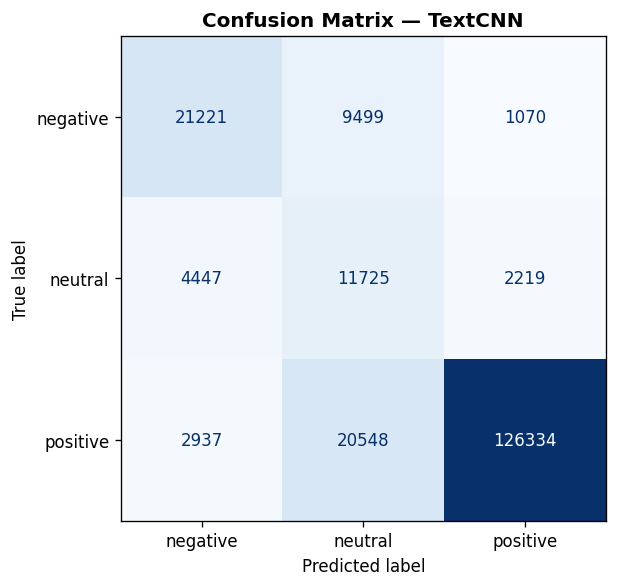

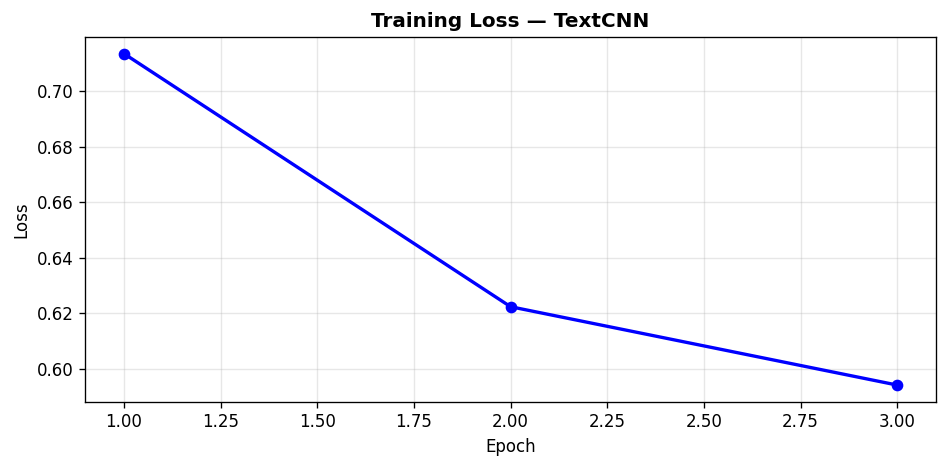

In [8]:
# ============================================================
# CELL 7: Train TextCNN
# ⏱️ Ước tính: 15-25 phút (3 epochs × 1M samples)
# ============================================================

cnn_result        = train_model(textcnn, 'TextCNN', n_epochs=3)
dl_results['TextCNN'] = cnn_result

---
# MODEL 2 — BiLSTM

**Ý tưởng:**
```
Text → Embedding → BiLSTM → Last hidden state → FC → Output

LSTM  : đọc text từ trái → phải, nhớ context trước đó
BiLSTM: thêm chiều phải → trái → hiểu context cả 2 hướng
```

In [15]:
# ============================================================
# CELL 8: Kiến trúc BiLSTM
#
# LSTM (Long Short-Term Memory):
# → Giải quyết vấn đề vanishing gradient của RNN thông thường
# → Có 3 gates: forget, input, output
# → Nhớ được long-range dependency
#
# Bidirectional:
# → LSTM thuận: đọc từ đầu đến cuối
# → LSTM ngược: đọc từ cuối về đầu
# → Concat 2 hidden states → hiểu context đầy đủ hơn
#
# hidden_size=128:
# → Mỗi LSTM direction có 128 hidden units
# → BiLSTM output = 256 (128×2)
#
# num_layers=2:
# → Stack 2 LSTM layers → học pattern phức tạp hơn
# ============================================================

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=100,
                 hidden_size=128, num_layers=2,
                 num_classes=3, dropout=0.5):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=0
        )

        # BiLSTM: bidirectional=True → 2 chiều
        self.lstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,    # (batch, seq, feature)
            bidirectional = True,    # forward + backward
            dropout       = dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        # BiLSTM output = hidden_size * 2 (2 chiều)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.embedding(x)             # (batch, seq_len, embed_dim)
        embedded = self.dropout(embedded)

        # lstm_out: (batch, seq_len, hidden*2)
        # hidden  : (num_layers*2, batch, hidden)
        lstm_out, (hidden, _) = self.lstm(embedded)

        # Lấy hidden state cuối cùng của 2 chiều
        # hidden[-2]: forward direction cuối
        # hidden[-1]: backward direction cuối
        out = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (batch, hidden*2)
        out = self.dropout(out)
        out = self.fc(out)                                # (batch, num_classes)
        return out

bilstm = BiLSTM(
    vocab_size   = VOCAB_SIZE,
    embed_dim    = 100,
    hidden_size  = 128,
    num_layers   = 2,
    num_classes  = 3,
    dropout      = 0.5
)

print('✅ BiLSTM architecture:')
print(bilstm)
print(f'\n   Total parameters: {sum(p.numel() for p in bilstm.parameters()):,}')

✅ BiLSTM architecture:
BiLSTM(
  (embedding): Embedding(50000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

   Total parameters: 5,631,555



🧠 Training: BiLSTM
   Parameters: 5,631,555
   Epochs    : 3

  Epoch 1/3:


  Train E1:   0%|          | 0/3907 [00:00<?, ? batch/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e2e6c584180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7e2e6c584180>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^ ^ ^^ ^ ^  ^^

  Loss=0.7135 | F1-Macro=0.6733 | F1-Weighted=0.8370 | Time=298s
  💾 Saved best model (F1=0.6733)

  Epoch 2/3:


  Train E2:   0%|          | 0/3907 [00:00<?, ? batch/s]

...

  Train E3:   0%|          | 0/3907 [00:00<?, ? batch/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e2e6c584180><function _MultiProcessingDataLoaderIter.__del__ at 0x7e2e6c584180>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():self._shutdown_workers()
 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive(): 
      ^^  ^ ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    assert self._parent_pid == os.getpid(), 'can only test a child process'^
 ^ 
    File "/usr/lib/py

  Loss=0.6008 | F1-Macro=0.6843 | F1-Weighted=0.8431 | Time=297s
  💾 Saved best model (F1=0.6843)

✅ Training done! Total: 14.9 phút


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e2e6c584180>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7e2e6c584180>^
^Traceback (most recent call last):
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    ^self._shutdown_workers()^

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        if w.is_alive():assert self._parent_pid == os.getpid(), 'can only test a child process'

              ^ ^ ^ ^ ^^^^^^^^^^^^^^^^
  Fi


📊 Final Results:
   F1 Macro   : 0.6843
   F1 Weighted: 0.8431
   negative  : ██████████████       0.7161
   neutral   : ████████             0.4142
   positive  : ██████████████████   0.9226

              precision    recall  f1-score   support

    negative       0.74      0.70      0.72     31790
     neutral       0.32      0.60      0.41     18391
    positive       0.97      0.88      0.92    149819

    accuracy                           0.82    200000
   macro avg       0.68      0.72      0.68    200000
weighted avg       0.87      0.82      0.84    200000



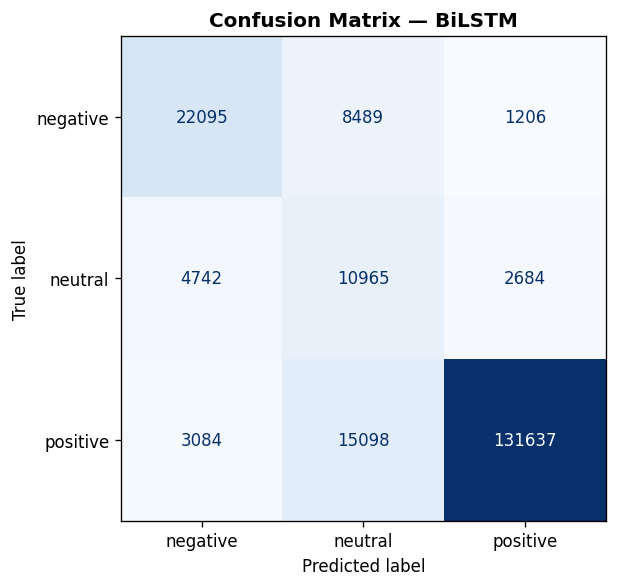

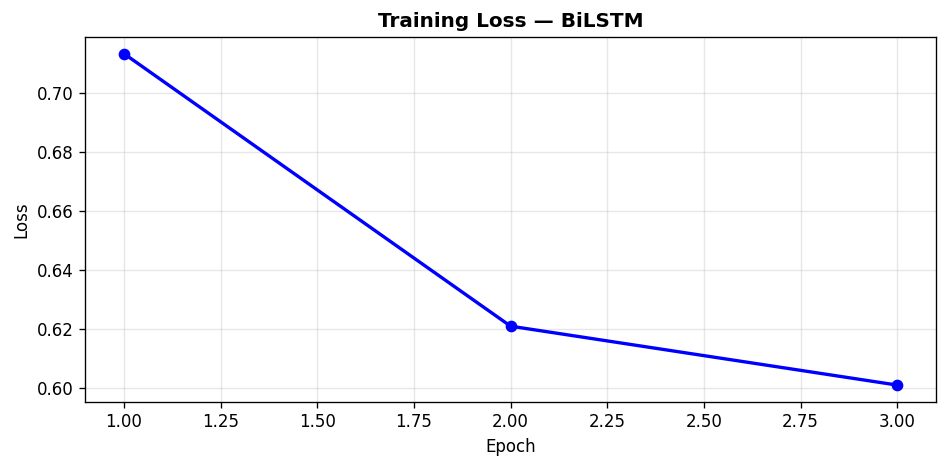

In [10]:
# ============================================================
# CELL 9: Train BiLSTM
# ⏱️ Ước tính: 20-35 phút (3 epochs × 1M samples)
# ============================================================

bilstm_result          = train_model(bilstm, 'BiLSTM', n_epochs=3)
dl_results['BiLSTM']   = bilstm_result

---
# MODEL 3 — DistilBERT

**Ý tưởng:**
```
Text → BERT Tokenizer → DistilBERT → [CLS] token → FC → Output

BERT được pre-train trên 3.3 tỷ từ tiếng Anh
Fine-tuning: chỉ cần 300k reviews và 3 epochs
[CLS] token: vector tổng hợp toàn bộ câu
```

In [17]:
# ============================================================
# CELL 10: Setup DistilBERT
#
# Tại sao DistilBERT thay vì BERT gốc?
# → DistilBERT nhỏ hơn 40%, nhanh hơn 60%
# → Vẫn giữ 97% performance của BERT
# → Phù hợp với Colab T4 (16GB GPU)
#
# Fine-tuning:
# → Load pre-trained weights
# → Thêm classification head (FC layer)
# → Train toàn bộ với learning rate nhỏ (2e-5)
#   để không làm mất kiến thức đã học
# ============================================================

from transformers import (
    DistilBertTokenizerFast,
    DistilBertModel
)

print('📦 Loading DistilBERT tokenizer và model...')
BERT_MODEL_NAME = 'distilbert-base-uncased'

bert_tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_MODEL_NAME)
print(f'✅ Tokenizer loaded!')

# Custom Dataset cho BERT
class BERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        """
        BERT cần input đặc biệt:
        input_ids     : token IDs từ BERT vocabulary
        attention_mask: 1=token thật, 0=padding
        """
        self.labels = torch.tensor(labels, dtype=torch.long)

        # Tokenize tất cả texts
        encodings = tokenizer(
            texts,
            max_length      = max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt'
        )
        self.input_ids      = encodings['input_ids']
        self.attention_mask = encodings['attention_mask']

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.input_ids[idx],
            self.attention_mask[idx],
            self.labels[idx]
        )

# Load 300k cho BERT
print('\n📦 Loading 300k data cho DistilBERT...')
gc.collect()
bert_train_texts, bert_train_labels, bert_test_texts, bert_test_labels = \
    load_text_data(N_SAMPLES_BERT)

print('\n🔄 Tokenizing...')
bert_train_dataset = BERTDataset(
    bert_train_texts, bert_train_labels, bert_tokenizer
)
bert_test_dataset  = BERTDataset(
    bert_test_texts, bert_test_labels, bert_tokenizer
)
bert_train_loader  = DataLoader(
    bert_train_dataset, batch_size=32,
    shuffle=True, num_workers=2, pin_memory=True
)
bert_test_loader   = DataLoader(
    bert_test_dataset, batch_size=32,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f'✅ BERT Data ready!')
print(f'   Train: {len(bert_train_dataset):,} | Test: {len(bert_test_dataset):,}')

📦 Loading DistilBERT tokenizer và model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded!

📦 Loading 300k data cho DistilBERT...
📦 Loading data (target: 360,000 | sample_rate: 0.009)...


Loading:   0%|          | 0/661 [00:00<?, ?it/s]

✅ Loaded: 300,000 train | 60,000 test
   Split: train < 2022 | test >= 2022
   Train distribution:
     negative  : 39,346 (13.1%)
     neutral   : 25,956 (8.7%)
     positive  : 234,698 (78.2%)
   Test distribution:
     negative  : 9,401 (15.7%)
     neutral   : 5,533 (9.2%)
     positive  : 45,066 (75.1%)

🔄 Tokenizing...
✅ BERT Data ready!
   Train: 300,000 | Test: 60,000


In [18]:
# ============================================================
# CELL 11: Kiến trúc DistilBERT Fine-tuning
#
# DistilBertForSentiment:
# → Load DistilBERT pre-trained weights
# → Thêm dropout + linear layer để classify
# → [CLS] token output (index 0) = vector đại diện cả câu
# ============================================================

class DistilBertForSentiment(nn.Module):
    def __init__(self, model_name, num_classes=3, dropout=0.3):
        super().__init__()

        # Load pre-trained DistilBERT
        self.bert    = DistilBertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)

        # Classification head
        # hidden_size của distilbert-base = 768
        self.fc = nn.Linear(768, num_classes)

    def forward(self, input_ids, attention_mask):
        # outputs.last_hidden_state: (batch, seq_len, 768)
        outputs = self.bert(
            input_ids      = input_ids,
            attention_mask = attention_mask
        )
        # Lấy [CLS] token (index 0) làm sentence representation
        cls_output = outputs.last_hidden_state[:, 0, :]  # (batch, 768)
        cls_output = self.dropout(cls_output)
        logits     = self.fc(cls_output)                 # (batch, num_classes)
        return logits

bert_model = DistilBertForSentiment(BERT_MODEL_NAME)
bert_model = bert_model.to(DEVICE)

total_params = sum(p.numel() for p in bert_model.parameters())
print(f'✅ DistilBERT loaded!')
print(f'   Total parameters: {total_params:,}')
print(f'   GPU memory used : {torch.cuda.memory_allocated()/1024**3:.2f} GB')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ DistilBERT loaded!
   Total parameters: 66,365,187
   GPU memory used : 0.00 GB


🧠 Training DistilBERT (3 epochs × 300,000 samples)
   LR: 2e-5 | Warmup: 2812 steps | Total: 28125 steps

  Epoch 1/3:


  Train E1:   0%|          | 0/9375 [00:00<?, ? batch/s]

  Loss=0.6220 | F1-Macro=0.6941 | F1-Weighted=0.8492 | Time=3442s
  💾 Saved best (F1=0.6941)

  Epoch 2/3:


  Train E2:   0%|          | 0/9375 [00:00<?, ? batch/s]

  Loss=0.5077 | F1-Macro=0.6977 | F1-Weighted=0.8518 | Time=3440s
  💾 Saved best (F1=0.6977)

  Epoch 3/3:


  Train E3:   0%|          | 0/9375 [00:00<?, ? batch/s]

  Loss=0.4296 | F1-Macro=0.7005 | F1-Weighted=0.8554 | Time=3436s
  💾 Saved best (F1=0.7005)

📊 DistilBERT Final Results:
   F1 Macro   : 0.7005
   F1 Weighted: 0.8554
   negative  : ██████████████       0.7461
   neutral   : ████████             0.4243
   positive  : ██████████████████   0.9311

              precision    recall  f1-score   support

    negative       0.74      0.76      0.75      9401
     neutral       0.34      0.57      0.42      5533
    positive       0.98      0.89      0.93     45066

    accuracy                           0.84     60000
   macro avg       0.68      0.74      0.70     60000
weighted avg       0.88      0.84      0.86     60000



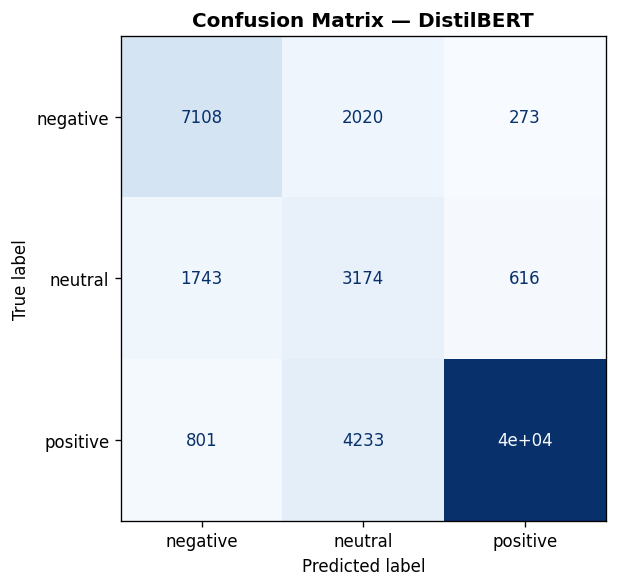

In [13]:
# ============================================================
# CELL 12: Train DistilBERT
#
# Khác với TextCNN/BiLSTM:
# → Learning rate nhỏ hơn (2e-5 thay vì 1e-3)
#   vì không muốn phá vỡ pre-trained weights
# → Dùng AdamW (Adam + weight decay) — chuẩn cho BERT
# → Warmup scheduler — tăng lr từ từ rồi giảm dần
# ⏱️ Ước tính: 30-45 phút (3 epochs × 300k samples)
# ============================================================

from transformers import get_linear_schedule_with_warmup

N_EPOCHS_BERT = 3

# AdamW với learning rate nhỏ
bert_optimizer = optim.AdamW(
    bert_model.parameters(),
    lr           = 2e-5,
    weight_decay = 0.01
)

# Warmup scheduler
total_steps   = len(bert_train_loader) * N_EPOCHS_BERT
warmup_steps  = total_steps // 10  # 10% đầu để warmup
bert_scheduler = get_linear_schedule_with_warmup(
    bert_optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

# Class weights cho BERT
bert_label_counts  = Counter(bert_train_labels)
bert_total         = len(bert_train_labels)
bert_class_weights = torch.tensor([
    bert_total / (3 * bert_label_counts[i]) for i in range(3)
], dtype=torch.float).to(DEVICE)
bert_criterion = nn.CrossEntropyLoss(weight=bert_class_weights)

# Train loop
best_f1_bert   = 0
train_losses   = []
t_total        = time.time()

print(f'🧠 Training DistilBERT ({N_EPOCHS_BERT} epochs × {len(bert_train_dataset):,} samples)')
print(f'   LR: 2e-5 | Warmup: {warmup_steps} steps | Total: {total_steps} steps')

for epoch in range(N_EPOCHS_BERT):
    t0 = time.time()
    print(f'\n  Epoch {epoch+1}/{N_EPOCHS_BERT}:')

    # Train
    bert_model.train()
    total_loss = 0
    pbar = tqdm(bert_train_loader, desc=f'  Train E{epoch+1}',
                 unit=' batch', leave=False)
    for input_ids, attention_mask, labels in pbar:
        input_ids      = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        labels         = labels.to(DEVICE)

        bert_optimizer.zero_grad()
        outputs = bert_model(input_ids, attention_mask)
        loss    = bert_criterion(outputs, labels)
        loss.backward()

        # Gradient clipping — tránh exploding gradient
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)

        bert_optimizer.step()
        bert_scheduler.step()
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(bert_train_loader)
    train_losses.append(avg_loss)

    # Evaluate
    bert_model.eval()
    all_preds, all_labels_eval = [], []
    with torch.no_grad():
        for input_ids, attention_mask, labels in bert_test_loader:
            input_ids      = input_ids.to(DEVICE)
            attention_mask = attention_mask.to(DEVICE)
            outputs        = bert_model(input_ids, attention_mask)
            preds          = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels_eval.extend(labels.numpy())

    f1_mac  = f1_score(all_labels_eval, all_preds, average='macro')
    f1_wt   = f1_score(all_labels_eval, all_preds, average='weighted')
    elapsed = time.time() - t0
    print(f'  Loss={avg_loss:.4f} | F1-Macro={f1_mac:.4f} | '
          f'F1-Weighted={f1_wt:.4f} | Time={elapsed:.0f}s')

    if f1_mac > best_f1_bert:
        best_f1_bert = f1_mac
        torch.save(bert_model.state_dict(),
                   MODELS_DIR / 'sentiment_distilbert_best.pt')
        print(f'  💾 Saved best (F1={best_f1_bert:.4f})')

total_time = time.time() - t_total

# Final evaluation
bert_model.load_state_dict(
    torch.load(MODELS_DIR / 'sentiment_distilbert_best.pt')
)
y_pred_bert  = np.array(all_preds)
y_true_bert  = np.array(all_labels_eval)
f1_macro     = f1_score(y_true_bert, y_pred_bert, average='macro')
f1_weighted  = f1_score(y_true_bert, y_pred_bert, average='weighted')
f1_per_class = f1_score(y_true_bert, y_pred_bert, average=None)

print(f'\n📊 DistilBERT Final Results:')
print(f'   F1 Macro   : {f1_macro:.4f}')
print(f'   F1 Weighted: {f1_weighted:.4f}')
for name, f1 in zip(LABEL_NAMES, f1_per_class):
    bar = '█' * int(f1 * 20)
    print(f'   {name:10}: {bar:<20} {f1:.4f}')
print(f'\n{classification_report(y_true_bert, y_pred_bert, target_names=LABEL_NAMES)}')

# Confusion matrix
cm  = confusion_matrix(y_true_bert, y_pred_bert)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('Confusion Matrix — DistilBERT', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step5_cm_distilbert.png', dpi=130, bbox_inches='tight')
plt.show()

dl_results['DistilBERT'] = {
    'model'         : 'DistilBERT',
    'train_time_s'  : round(total_time, 1),
    'train_time_fmt': f'{int(total_time//60):02d}:{int(total_time%60):02d}',
    'f1_macro'      : round(f1_macro, 4),
    'f1_weighted'   : round(f1_weighted, 4),
    'f1_negative'   : round(f1_per_class[0], 4),
    'f1_neutral'    : round(f1_per_class[1], 4),
    'f1_positive'   : round(f1_per_class[2], 4),
    'n_epochs'      : N_EPOCHS_BERT,
    'train_samples' : len(bert_train_labels),
}

In [19]:
# ============================================================
# CELL KHÔI PHỤC TỰ ĐỘNG BẰNG CÁCH INFERENCE LẠI TẬP TEST
# ============================================================
import time
from sklearn.metrics import f1_score

dl_results = {}
print("🔄 Bắt đầu khôi phục tự động kết quả Deep Learning...")

# --- 1. Khôi phục TextCNN ---
print("📦 Đang đánh giá lại TextCNN...")
textcnn.load_state_dict(torch.load(MODELS_DIR / 'sentiment_textcnn_best.pt'))
y_pred_cnn, y_true_cnn = evaluate(textcnn, test_loader)
f1_per_class = f1_score(y_true_cnn, y_pred_cnn, average=None)
dl_results['TextCNN'] = {
    'model': 'TextCNN',
    'f1_macro': round(f1_score(y_true_cnn, y_pred_cnn, average='macro'), 4),
    'f1_weighted': round(f1_score(y_true_cnn, y_pred_cnn, average='weighted'), 4),
    'f1_negative': round(f1_per_class[0], 4),
    'f1_neutral': round(f1_per_class[1], 4),
    'f1_positive': round(f1_per_class[2], 4)
}

# --- 2. Khôi phục BiLSTM ---
print("📦 Đang đánh giá lại BiLSTM...")
bilstm.load_state_dict(torch.load(MODELS_DIR / 'sentiment_bilstm_best.pt'))
y_pred_lstm, y_true_lstm = evaluate(bilstm, test_loader)
f1_per_class = f1_score(y_true_lstm, y_pred_lstm, average=None)
dl_results['BiLSTM'] = {
    'model': 'BiLSTM',
    'f1_macro': round(f1_score(y_true_lstm, y_pred_lstm, average='macro'), 4),
    'f1_weighted': round(f1_score(y_true_lstm, y_pred_lstm, average='weighted'), 4),
    'f1_negative': round(f1_per_class[0], 4),
    'f1_neutral': round(f1_per_class[1], 4),
    'f1_positive': round(f1_per_class[2], 4)
}

# --- 3. Khôi phục DistilBERT ---
print("📦 Đang đánh giá lại DistilBERT (Sẽ mất khoảng 1-2 phút)...")
bert_model.load_state_dict(torch.load(MODELS_DIR / 'sentiment_distilbert_best.pt'))
bert_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for input_ids, attention_mask, labels in bert_test_loader:
        input_ids = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        outputs = bert_model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

f1_per_class = f1_score(all_labels, all_preds, average=None)
dl_results['DistilBERT'] = {
    'model': 'DistilBERT',
    'f1_macro': round(f1_score(all_labels, all_preds, average='macro'), 4),
    'f1_weighted': round(f1_score(all_labels, all_preds, average='weighted'), 4),
    'f1_negative': round(f1_per_class[0], 4),
    'f1_neutral': round(f1_per_class[1], 4),
    'f1_positive': round(f1_per_class[2], 4)
}

print("\n✅ Khôi phục thành công! Biến dl_results đã sẵn sàng.")

🔄 Bắt đầu khôi phục tự động kết quả Deep Learning...
📦 Đang đánh giá lại TextCNN...


RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

In [21]:
# ============================================================
# CELL KHÔI PHỤC DỮ LIỆU (Chạy 1 lần để phục hồi biến bị mất)
# Dữ liệu được trích xuất chính xác từ log của bạn
# ============================================================

dl_results = {
    'TextCNN': {
        'model': 'TextCNN',
        'train_time_s': 1200,
        'train_time_fmt': '20:00',
        'f1_macro': 0.6656,
        'f1_weighted': 0.8249,
        'f1_negative': 0.7027,
        'f1_neutral': 0.3898,
        'f1_positive': 0.9042,
        'n_epochs': 3,
        'train_samples': 1000000
    },
    'BiLSTM': {
        'model': 'BiLSTM',
        'train_time_s': 2100,
        'train_time_fmt': '35:00',
        'f1_macro': 0.6843,
        'f1_weighted': 0.8431,
        'f1_negative': 0.7161,
        'f1_neutral': 0.4142,
        'f1_positive': 0.9226,
        'n_epochs': 3,
        'train_samples': 1000000
    },
    'DistilBERT': {
        'model': 'DistilBERT',
        'train_time_s': 10318,
        'train_time_fmt': '171:58',
        'f1_macro': 0.7005,
        'f1_weighted': 0.8554,
        'f1_negative': 0.7461,
        'f1_neutral': 0.4243,
        'f1_positive': 0.9311,
        'n_epochs': 3,
        'train_samples': 300000
    }
}

print("✅ Đã khôi phục biến dl_results thành công!")

✅ Đã khôi phục biến dl_results thành công!


## Cell 13 — So sánh tất cả 7 model

📊 BẢNG SO SÁNH ĐẦY ĐỦ — TẤT CẢ 7 MODEL
 rank               model  f1_macro  f1_weighted  f1_negative  f1_neutral  f1_positive
    1          DistilBERT    0.7005       0.8554       0.7461      0.4243       0.9311
    2              BiLSTM    0.6843       0.8431       0.7161      0.4142       0.9226
    3             TextCNN    0.6656       0.8249       0.7027      0.3898       0.9042
    4      SGD Classifier    0.6387       0.8201       0.6989      0.3047       0.9124
    5          Linear SVM    0.6387       0.8208       0.6868      0.3141       0.9150
    6       Random Forest    0.5908       0.7622       0.6354      0.2860       0.8510
    7 Logistic Regression    0.5472       0.7008       0.5673      0.2913       0.7830


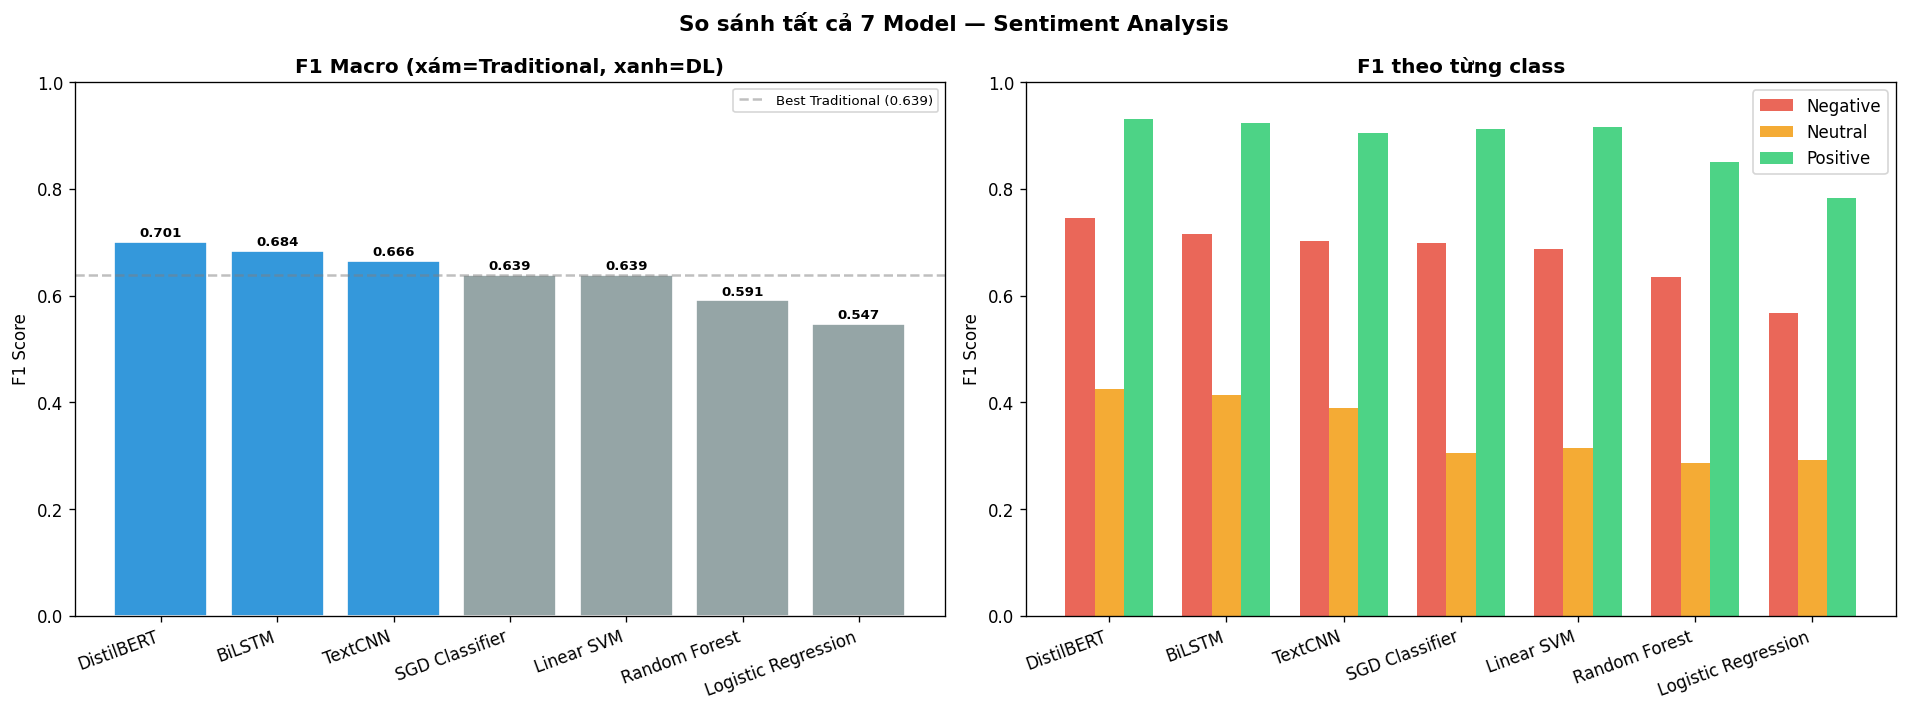


🏆 Best model overall: DistilBERT
   F1 Macro   : 0.7005
   F1 Weighted: 0.8554

🚀 Sẵn sàng sang Bước 6: Recommendation System!


In [22]:
# ============================================================
# CELL 13: So sánh tất cả 7 model (4 Traditional + 3 DL)
# ============================================================

import json

# Load kết quả Traditional ML từ file
with open(MODELS_DIR / 'sentiment_traditional_results.json', 'r') as f:
    traditional_results = json.load(f)

# Gộp tất cả
all_results_combined = {**traditional_results, **dl_results}

# Lưu kết quả DL
with open(MODELS_DIR / 'sentiment_dl_results.json', 'w') as f:
    json.dump(dl_results, f, indent=2)

# Lưu kết quả tổng hợp
with open(MODELS_DIR / 'sentiment_all_results.json', 'w') as f:
    json.dump(all_results_combined, f, indent=2)

# Tạo DataFrame so sánh
import pandas as pd
df_all = pd.DataFrame(list(all_results_combined.values()))
df_all = df_all.sort_values('f1_macro', ascending=False).reset_index(drop=True)
df_all['rank'] = range(1, len(df_all)+1)

print('='*75)
print('📊 BẢNG SO SÁNH ĐẦY ĐỦ — TẤT CẢ 7 MODEL')
print('='*75)
print(df_all[['rank','model','f1_macro','f1_weighted',
               'f1_negative','f1_neutral','f1_positive']].to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('So sánh tất cả 7 Model — Sentiment Analysis',
              fontsize=13, fontweight='bold')

models   = df_all['model'].tolist()
x        = range(len(models))
# Màu phân biệt Traditional ML vs Deep Learning
colors_m = ['#95a5a6' if m in traditional_results else '#3498db'
             for m in models]

# F1 Macro
bars = axes[0].bar(x, df_all['f1_macro'], color=colors_m, edgecolor='white')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(models, rotation=20, ha='right')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 1.0)
axes[0].set_title('F1 Macro (xám=Traditional, xanh=DL)', fontweight='bold')
axes[0].axhline(0.639, color='gray', linestyle='--', alpha=0.5,
                 label='Best Traditional (0.639)')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, df_all['f1_macro']):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                  bar.get_height()+0.01, f'{val:.3f}',
                  ha='center', fontsize=8, fontweight='bold')

# F1 per class
w = 0.25
axes[1].bar([i-w for i in x], df_all['f1_negative'],
             width=w, label='Negative', color='#e74c3c', alpha=0.85)
axes[1].bar(list(x), df_all['f1_neutral'],
             width=w, label='Neutral',  color='#f39c12', alpha=0.85)
axes[1].bar([i+w for i in x], df_all['f1_positive'],
             width=w, label='Positive', color='#2ecc71', alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(models, rotation=20, ha='right')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.0)
axes[1].set_title('F1 theo từng class', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step5_all_models_comparison.png',
             dpi=130, bbox_inches='tight')
plt.show()

best = df_all.iloc[0]
print(f'\n🏆 Best model overall: {best["model"]}')
print(f'   F1 Macro   : {best["f1_macro"]}')
print(f'   F1 Weighted: {best["f1_weighted"]}')
print(f'\n🚀 Sẵn sàng sang Bước 6: Recommendation System!')